# SEÇÃO 1 — CAPA E OBJETIVO

# 📘 MVP de Machine Learning & Analytics para Fundos de Investimento

## Análise Preditiva da Rentabilidade de Fundos Utilizando Machine Learning

**Aluno:** Paulo Ricardo Marques Leite

**Matrícula:** 4052025002553

---

# Objetivo Geral

Este trabalho tem como objetivo desenvolver um MVP completo de Machine Learning & Analytics capaz de prever o retorno anual (`returns_1yr`) de fundos de investimento a partir de métricas de risco, desempenho histórico, custos operacionais e características estruturais dos fundos.

O estudo segue o ciclo completo de um projeto de Ciência de Dados:

* Definição do problema
* Compreensão dos dados
* Análise exploratória
* Preparação dos dados
* Engenharia de atributos
* Modelagem
* Otimização de hiperparâmetros
* Avaliação
* Interpretação dos resultados
* Conclusões

---

# Tipo de Problema

Trata-se de um problema supervisionado de **Regressão**, pois o objetivo é prever uma variável numérica contínua (`returns_1yr`).

---

# Pergunta de Negócio

Quais características dos fundos de investimento mais influenciam sua rentabilidade anual e até que ponto é possível prever esse retorno utilizando técnicas de Machine Learning?


# SEÇÃO 2 — IMPORTAÇÃO DAS BIBLIOTECAS

In [1]:
# ==========================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from math import sqrt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import Ridge

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

SEED = 42
np.random.seed(SEED)

plt.style.use("seaborn-v0_8")

pd.set_option("display.max_columns", None)

print("Ambiente configurado com sucesso.")

Ambiente configurado com sucesso.


# SEÇÃO 3 — CARREGAMENTO DOS DADOS

# Apresentação dos Dados

O dataset utilizado contém informações sobre fundos de investimento, incluindo métricas de risco, rentabilidade histórica, custos operacionais e características estruturais.

A base será carregada diretamente a partir de uma URL pública do GitHub, garantindo total reprodutibilidade do projeto.


In [2]:
url = "https://raw.githubusercontent.com/pleiteues-code/mvp-machine-learning-analytics/refs/heads/main/comprehensive_mutual_funds_data.csv"

df = pd.read_csv(url)

print("Dimensões:", df.shape)

df.head()

Dimensões: (814, 20)


,scheme_name,min_sip,min_lumpsum,expense_ratio,fund_size_cr,fund_age_yr,fund_manager,sortino,alpha,sd,beta,sharpe,risk_level,amc_name,rating,category,sub_category,returns_1yr,returns_3yr,returns_5yr
0,Aditya Birla SL Active Debt Multi-Mgr FoF-Dir ...,100,100,0.27,10.0,10,Kaustubh Gupta,0.32,2.24,9.39,0.01,0.24,3,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,4.0,6.5,6.9
1,Aditya Birla SL Arbitrage Fund,1000,1000,0.36,4288.0,10,Lovelish Solanki,1.33,1.53,0.72,0.56,1.1,1,Aditya Birla Sun Life Mutual Fund,3,Hybrid,Arbitrage Mutual Funds,5.6,4.8,5.5
2,Aditya Birla SL Asset Allocator FoF-Dir Growth,1000,1000,0.53,157.0,10,Vinod Narayan Bhat,3.44,2.67,10.58,0.67,1.42,5,Aditya Birla Sun Life Mutual Fund,3,Other,FoFs Domestic,2.0,18.9,9.7
3,Aditya Birla SL Bal Bhavishya Yojna – Dir Growth,500,1000,0.76,637.0,4,Atul Penkar,2.18,-6.37,14.99,0.85,0.9,6,Aditya Birla Sun Life Mutual Fund,2,Solution Oriented,Childrens Funds,-0.7,17.1,NaN
4,Aditya Birla SL Balanced Advantage Fund,100,100,0.61,6386.0,10,Mohit Sharma,3.69,1.99,10.38,0.68,1.39,6,Aditya Birla Sun Life Mutual Fund,4,Hybrid,Dynamic Asset Allocation or Balanced Advantage,4.5,18.6,9.7


# SEÇÃO 4 — DESCRIÇÃO DOS DADOS

In [3]:
print("Informações gerais:")
display(df.info())

print("\nValores ausentes:")
display(df.isnull().sum())

print("\nEstatísticas descritivas:")
display(df.describe().T)

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_name    814 non-null    object 
 1   min_sip        814 non-null    int64  
 2   min_lumpsum    814 non-null    int64  
 3   expense_ratio  814 non-null    float64
 4   fund_size_cr   814 non-null    float64
 5   fund_age_yr    814 non-null    int64  
 6   fund_manager   814 non-null    object 
 7   sortino        814 non-null    object 
 8   alpha          814 non-null    object 
 9   sd             814 non-null    object 
 10  beta           814 non-null    object 
 11  sharpe         814 non-null    object 
 12  risk_level     814 non-null    int64  
 13  amc_name       814 non-null    object 
 14  rating         814 non-null    int64  
 15  category       814 non-null    object 
 16  sub_category   814 non-null    object 
 17  returns_1yr    814 non-null    flo

None


Valores ausentes:


,0
scheme_name,0
min_sip,0
min_lumpsum,0
expense_ratio,0
fund_size_cr,0
fund_age_yr,0
fund_manager,0
sortino,0
alpha,0
sd,0



Estatísticas descritivas:


,count,mean,std,min,25%,50%,75%,max
min_sip,814.0,528.500000,369.184517,0.00,150.00,500.000,1000.00,2000.00
min_lumpsum,814.0,3047.468059,2514.619513,0.00,500.00,5000.000,5000.00,25000.00
expense_ratio,814.0,0.713231,0.482161,0.00,0.31,0.615,1.03,2.59
fund_size_cr,814.0,3812.854214,7181.479475,2.38,175.25,940.500,3819.00,57052.00
fund_age_yr,814.0,8.319410,2.640622,1.00,6.00,10.000,10.00,17.00
risk_level,814.0,4.400491,1.814741,1.00,3.00,6.000,6.00,6.00
rating,814.0,2.641278,1.463476,0.00,2.00,3.000,4.00,5.00
returns_1yr,814.0,3.921376,6.675502,-19.70,1.50,4.400,5.60,130.80
returns_3yr,793.0,18.525347,12.108476,3.30,6.20,18.500,27.10,71.40
returns_5yr,647.0,9.490726,3.714015,-4.10,6.70,8.900,12.20,23.20


In [4]:
print("Quantidade de registros:", df.shape[0])
print("Quantidade de atributos:", df.shape[1])

print("\nColunas:")
for col in df.columns:
    print(col)

Quantidade de registros: 814
Quantidade de atributos: 20

Colunas:
scheme_name
min_sip
min_lumpsum
expense_ratio
fund_size_cr
fund_age_yr
fund_manager
sortino
alpha
sd
beta
sharpe
risk_level
amc_name
rating
category
sub_category
returns_1yr
returns_3yr
returns_5yr


# SEÇÃO 5 — ANÁLISE EXPLORATÓRIA

Nesta etapa investigamos:

* distribuição da variável-alvo;
* correlações;
* presença de outliers;
* comportamento dos retornos;
* diferenças entre categorias de fundos.

O objetivo é compreender melhor os dados antes da modelagem.


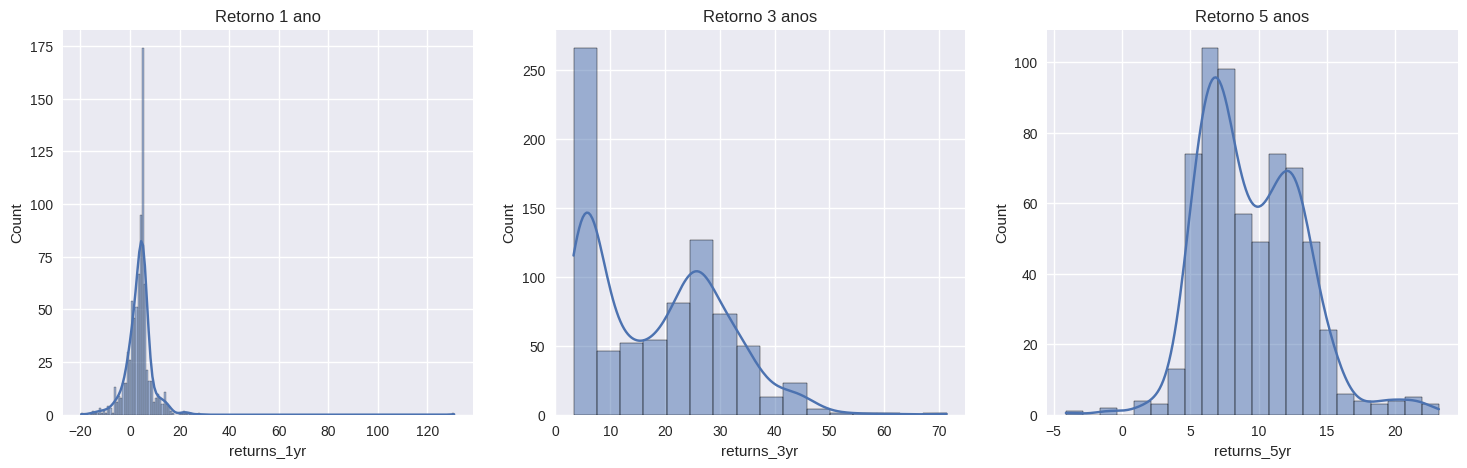

In [5]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.histplot(df["returns_1yr"], kde=True, ax=axes[0])
axes[0].set_title("Retorno 1 ano")

sns.histplot(df["returns_3yr"], kde=True, ax=axes[1])
axes[1].set_title("Retorno 3 anos")

sns.histplot(df["returns_5yr"], kde=True, ax=axes[2])
axes[2].set_title("Retorno 5 anos")

plt.show()

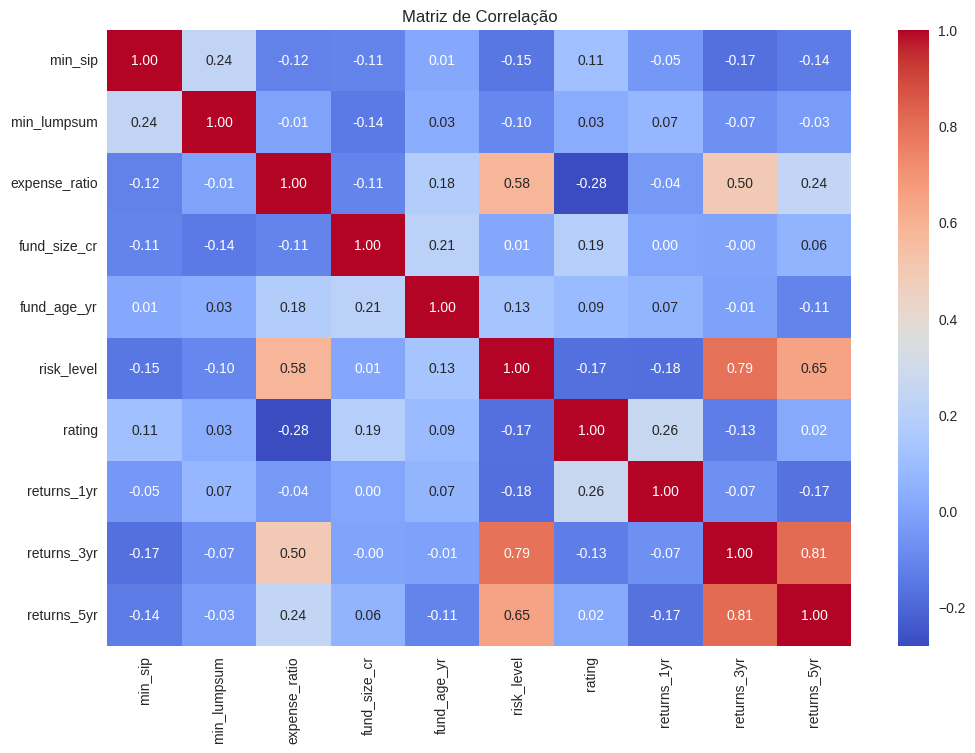

In [6]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de Correlação")
plt.show()

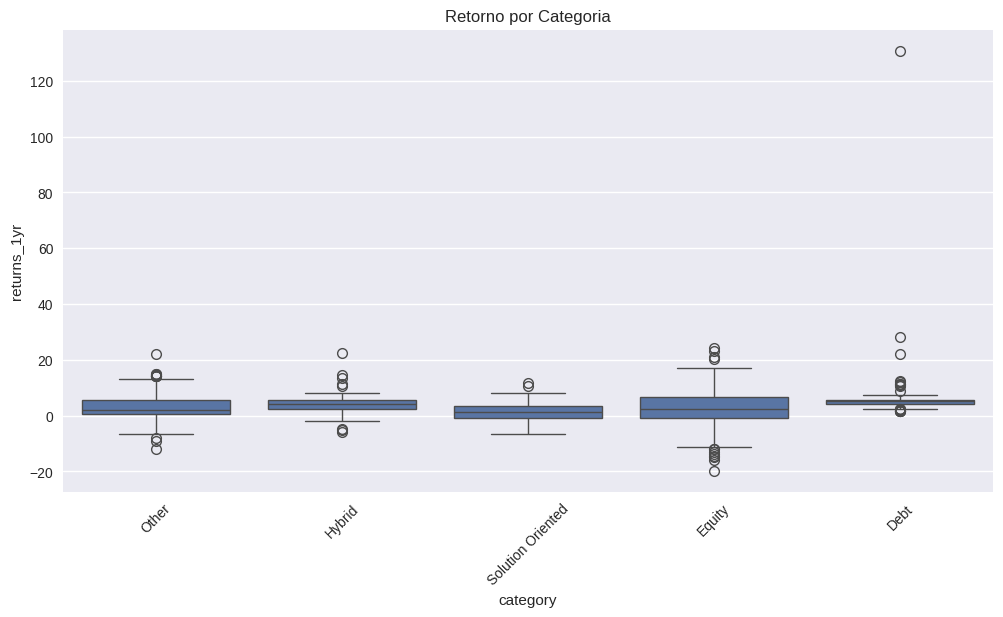

In [7]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="category",
    y="returns_1yr"
)

plt.xticks(rotation=45)

plt.title("Retorno por Categoria")

plt.show()

# SEÇÃO 6 — PREPARAÇÃO DOS DADOS

Antes da modelagem, é necessário preparar os dados para que os algoritmos possam utilizá-los adequadamente.

**As principais etapas realizadas foram:**

* conversão de atributos numéricos armazenados como texto;
* tratamento de valores ausentes;
* remoção de atributos com baixa capacidade preditiva;
* criação de novos atributos derivados (engenharia de atributos);
* separação entre variáveis explicativas e variável-alvo;
* construção de pipelines reproduzíveis para evitar vazamento de dados.

Todas as transformações serão realizadas dentro dos pipelines, garantindo que os dados de teste permaneçam completamente isolados durante o treinamento.


## 6.1 Conversão de Tipos

In [8]:
# ==========================================
# CONVERSÃO DE COLUNAS NUMÉRICAS
# ==========================================

cols_numeric_text = [
    "sortino",
    "alpha",
    "sd",
    "beta",
    "sharpe"
]

for col in cols_numeric_text:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[cols_numeric_text].dtypes)

sortino    float64
alpha      float64
sd         float64
beta       float64
sharpe     float64
dtype: object


## 6.2 Verificação Final dos Ausentes

In [9]:
missing_df = pd.DataFrame(
    df.isnull().sum(),
    columns=["missing"]
)

missing_df["percent"] = (
    missing_df["missing"] / len(df)
) * 100

missing_df.sort_values(
    by="missing",
    ascending=False
)

,missing,percent
returns_5yr,167,20.515971
beta,42,5.159705
alpha,42,5.159705
sd,24,2.948403
sharpe,23,2.825553
sortino,23,2.825553
returns_3yr,21,2.579853
scheme_name,0,0.000000
expense_ratio,0,0.000000
min_lumpsum,0,0.000000


## 6.3 Engenharia de Atributos


Além das variáveis originais, foram criadas novas métricas derivadas com o objetivo de capturar relações financeiras potencialmente relevantes.

Essas variáveis procuram representar:

* consistência histórica de desempenho;
* relação entre risco e retorno;
* crescimento ao longo do tempo;
* eficiência operacional do fundo.

A criação de atributos é uma etapa frequentemente utilizada em projetos de Machine Learning para aumentar o poder explicativo dos modelos.


In [10]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

df["return_gap"] = (
    df["returns_3yr"] - df["returns_5yr"]
)

df["risk_return_ratio"] = (
    df["sharpe"] /
    (df["risk_level"] + 1)
)

df["size_age_ratio"] = (
    df["fund_size_cr"] /
    (df["fund_age_yr"] + 1)
)

df["expense_per_rating"] = (
    df["expense_ratio"] /
    (df["rating"] + 1)
)

print("Novas features criadas.")

Novas features criadas.


## 6.4 Definição da Variável-Alvo

In [11]:
target = "returns_1yr"

y = df[target]

## 6.5 Remoção de Colunas Não Utilizadas

## Seleção de Atributos

Algumas variáveis foram removidas da modelagem:

* `scheme_name`
* `fund_manager`

Esses atributos possuem alta cardinalidade e baixa capacidade de generalização, podendo introduzir ruído ao modelo.

A remoção busca reduzir complexidade sem perda relevante de informação.


In [12]:
drop_cols = [
    "returns_1yr",
    "scheme_name",
    "fund_manager"
]

X = df.drop(columns=drop_cols)

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (814, 21)
Shape y: (814,)


## 6.6 Separação Numéricas e Categóricas

In [13]:
cat_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

num_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Numéricas:", len(num_features))
print("Categóricas:", len(cat_features))

print("\nCategóricas:")
print(cat_features)

Numéricas: 18
Categóricas: 3

Categóricas:
['amc_name', 'category', 'sub_category']


## 6.7 Divisão Treino/Teste

## Divisão dos Dados

Os dados foram divididos em conjuntos de treino e teste.

A divisão adotada foi:

* 80% para treinamento
* 20% para teste

O conjunto de teste será utilizado exclusivamente na avaliação final dos modelos, permitindo uma estimativa mais realista da capacidade de generalização.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (651, 21)
Teste : (163, 21)


## 6.8 Pipeline Sem Data Leakage

In [15]:
# ==========================================
# PIPELINE NUMÉRICO
# ==========================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# ==========================================
# PIPELINE CATEGÓRICO
# ==========================================

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# ==========================================
# PREPROCESSADOR
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            num_features
        ),
        (
            "cat",
            categorical_transformer,
            cat_features
        )
    ]
)

print("Pipeline criado com sucesso.")

Pipeline criado com sucesso.


## 6.9 Verificação de Vazamento

### Controle de Vazamento de Dados

Todas as operações de imputação, normalização e codificação serão ajustadas exclusivamente com os dados de treinamento através do Pipeline.

Essa abordagem elimina vazamento de informação (data leakage) e segue as boas práticas recomendadas para projetos de Machine Learning.


# SEÇÃO 7 — MODELAGEM E COMPARAÇÃO DE MODELOS

## 7.1 Função de Avaliação

In [16]:
# ==========================================
# FUNÇÃO DE AVALIAÇÃO
# ==========================================

def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_r2 = r2_score(y_train, pred_train)

    test_r2 = r2_score(y_test, pred_test)

    mae = mean_absolute_error(y_test, pred_test)

    rmse = np.sqrt(
        mean_squared_error(y_test, pred_test)
    )

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    return {
        "Model": name,
        "Train_R2": train_r2,
        "Test_R2": test_r2,
        "CV_R2_Mean": cv_scores.mean(),
        "CV_R2_STD": cv_scores.std(),
        "MAE": mae,
        "RMSE": rmse
    }

## 7.2 Modelo Baseline

Antes de treinar modelos mais sofisticados, é importante estabelecer uma referência simples.

O Dummy Regressor prevê sempre a média da variável-alvo observada no conjunto de treinamento.

Qualquer modelo útil deve superar significativamente esse baseline.


In [17]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor())
    ]
)

## 7.3 Ridge Regression

A regressão Ridge é uma extensão da regressão linear tradicional que adiciona regularização para reduzir overfitting.

Ela será utilizada como modelo linear de referência.


In [18]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            Ridge(alpha=1.0)
        )
    ]
)

## 7.4 Random Forest

O Random Forest é um modelo baseado em múltiplas árvores de decisão.

Sua principal vantagem é capturar relações não lineares e interações complexas entre atributos.


In [19]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

## 7.5 Gradient Boosting

O Gradient Boosting constrói árvores sequencialmente, corrigindo os erros das árvores anteriores.

É um dos algoritmos mais utilizados em competições e aplicações de Machine Learning para dados tabulares.


In [20]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=SEED
            )
        )
    ]
)

## 7.6 Avaliação dos Modelos

In [21]:
results = []

results.append(
    evaluate_model(
        "Baseline",
        baseline_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

results.append(
    evaluate_model(
        "Ridge",
        ridge_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        rf_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        gb_model,
        X_train,
        X_test,
        y_train,
        y_test
    )
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test_R2",
    ascending=False
)

results_df

,Model,Train_R2,Test_R2,CV_R2_Mean,CV_R2_STD,MAE,RMSE
2,Random Forest,0.868641,0.516811,0.342187,0.215726,2.087072,3.816093
3,Gradient Boosting,0.926198,0.516189,0.372767,0.187626,2.219628,3.818549
1,Ridge,0.701455,0.279815,0.247866,0.119503,3.055865,4.658891
0,Baseline,0.000000,-0.008892,-0.006371,0.004749,3.548004,5.514206


## 7.7 Ranking dos Modelos

In [22]:
display(
    results_df.style.format(
        {
            "Train_R2":"{:.3f}",
            "Test_R2":"{:.3f}",
            "CV_R2_Mean":"{:.3f}",
            "CV_R2_STD":"{:.3f}",
            "MAE":"{:.3f}",
            "RMSE":"{:.3f}"
        }
    )
)

,Model,Train_R2,Test_R2,CV_R2_Mean,CV_R2_STD,MAE,RMSE
2,Random Forest,0.869,0.517,0.342,0.216,2.087,3.816
3,Gradient Boosting,0.926,0.516,0.373,0.188,2.220,3.819
1,Ridge,0.701,0.280,0.248,0.120,3.056,4.659
0,Baseline,0.000,-0.009,-0.006,0.005,3.548,5.514


## 7.8 Visualização Comparativa

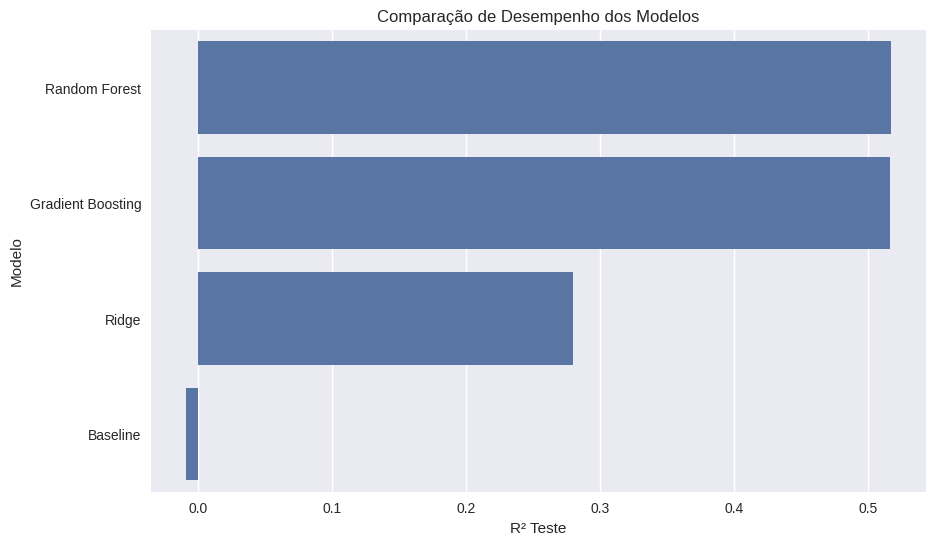

In [23]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Test_R2",
    y="Model"
)

plt.title(
    "Comparação de Desempenho dos Modelos"
)

plt.xlabel("R² Teste")

plt.ylabel("Modelo")

plt.show()

## 7.9 Interpretação

Os resultados mostram que os modelos baseados em árvores apresentaram desempenho significativamente superior aos modelos lineares.

O modelo Baseline apresentou R² próximo de zero, indicando que simplesmente prever a média dos retornos não é suficiente para explicar a variabilidade observada nos dados.

A Regressão Ridge apresentou melhora relevante em relação ao Baseline, alcançando R² de aproximadamente 0,28 no conjunto de teste. Esse resultado sugere que existe relação linear entre parte das variáveis explicativas e a rentabilidade anual dos fundos.

Entretanto, os melhores desempenhos foram obtidos pelos modelos Random Forest e Gradient Boosting, ambos alcançando R² próximo de 0,52 no conjunto de teste.

O Random Forest apresentou o melhor desempenho geral, com:

* maior R² no conjunto de teste (0,517);
* menor erro absoluto médio (MAE = 2,087);
* menor RMSE (3,816).

Além disso, o modelo demonstrou boa capacidade de generalização, embora exista evidência de overfitting moderado, uma vez que o desempenho no treinamento (R² = 0,869) foi superior ao observado no conjunto de teste.

O Gradient Boosting apresentou desempenho muito semelhante ao Random Forest, porém com erro médio ligeiramente maior e indícios mais fortes de overfitting (R² de treinamento = 0,926).

Dessa forma, o Random Forest será selecionado para a etapa de otimização de hiperparâmetros, por apresentar o melhor equilíbrio entre capacidade preditiva, estabilidade e interpretabilidade.

A utilização de validação cruzada permitiu reduzir a dependência de uma única divisão treino/teste, fornecendo evidências mais robustas sobre o comportamento esperado dos modelos em novos dados.


## SEÇÃO 8 — OTIMIZAÇÃO DO RANDOM FOREST

Após a comparação inicial dos modelos, o Random Forest foi selecionado para a etapa de otimização por apresentar o melhor equilíbrio entre desempenho preditivo, estabilidade e interpretabilidade.

O objetivo desta etapa é encontrar uma combinação de hiperparâmetros capaz de melhorar a capacidade de generalização do modelo sem utilizar informações do conjunto de teste.

Para isso será utilizado o RandomizedSearchCV com validação cruzada de 5 folds.

Essa abordagem permite explorar diferentes configurações de forma eficiente, reduzindo o custo computacional quando comparada à busca exaustiva (Grid Search).


## 8.1 Pipeline para Otimização

In [24]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

## 8.2 Espaço de Hipóteses

In [25]:
param_dist = {

    "model__n_estimators": [
        200,
        300,
        500,
        700
    ],

    "model__max_depth": [
        None,
        5,
        10,
        15,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10,
        15
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        None
    ]
}

## 8.3 Randomized Search

> ⚠️ **Atenção:** A próxima célula leva cerca de **5 minutos** para ser concluída.


In [26]:
random_search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=param_dist,

    n_iter=30,

    cv=5,

    scoring="r2",

    random_state=SEED,

    n_jobs=-1,

    verbose=1

)

random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['min_sip',
                                                                                'min_lumpsum',
                                                                                'expense_ratio',
                                                                                'fund_size_cr',
                                                                                'fund_age_yr',
                                                                                'sortino',
                                                                                'alpha',
                                                                                'sd',
                                                                                'beta',
                                                                                'sharpe',
                                                                                'risk_level',
                                                                                'rating',
                                                                                'returns_3yr',
                                                                                'returns_...
                                                                                'sub_category'])])),
                                             ('model',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                             20, 30],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4, 8],
                                        'model__min_samples_split': [2, 5, 10,
                                                                     15],
                                        'model__n_estimators': [200, 300, 500,
                                                                700]},
                   random_state=42, scoring='r2', verbose=1)

## 8.4 Melhores Hiperparâmetros

In [27]:
print("Melhores parâmetros:\n")

print(random_search.best_params_)

print("\nMelhor CV R²:")

print(
    round(
        random_search.best_score_,
        4
    )
)

Melhores parâmetros:

{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 20}

Melhor CV R²:
0.3477


## 8.5 Melhor Modelo

In [28]:
best_rf = random_search.best_estimator_

## 8.6 Avaliação Final do Modelo Otimizado

In [29]:
pred_train = best_rf.predict(X_train)

pred_test = best_rf.predict(X_test)

rf_train_r2 = r2_score(
    y_train,
    pred_train
)

rf_test_r2 = r2_score(
    y_test,
    pred_test
)

rf_mae = mean_absolute_error(
    y_test,
    pred_test
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_test
    )
)

print(f"Train R² : {rf_train_r2:.3f}")
print(f"Test R²  : {rf_test_r2:.3f}")
print(f"MAE      : {rf_mae:.3f}")
print(f"RMSE     : {rf_rmse:.3f}")

Train R² : 0.876
Test R²  : 0.515
MAE      : 2.070
RMSE     : 3.823


## 8.7 Comparação Antes x Depois

In [30]:
comparison = pd.DataFrame({

    "Modelo": [
        "Random Forest Inicial",
        "Random Forest Otimizado"
    ],

    "Test_R2": [
        0.517,
        rf_test_r2
    ],

    "MAE": [
        2.087,
        rf_mae
    ],

    "RMSE": [
        3.816,
        rf_rmse
    ]
})

comparison

,Modelo,Test_R2,MAE,RMSE
0,Random Forest Inicial,0.517000,2.087000,3.816000
1,Random Forest Otimizado,0.515075,2.069819,3.822945


## 8.8 Visualização

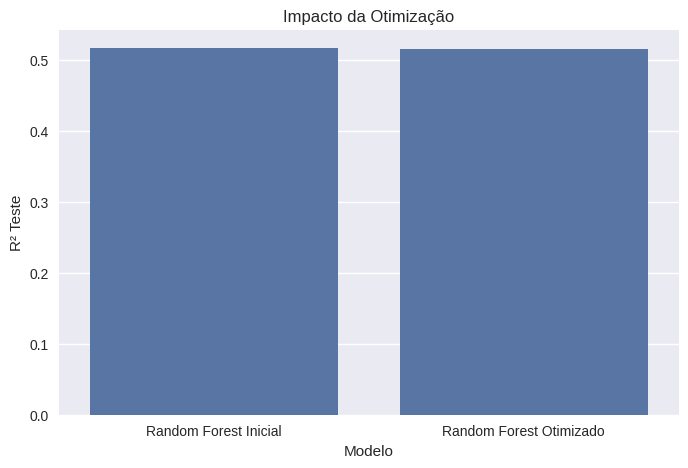

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Modelo",
    y="Test_R2"
)

plt.title(
    "Impacto da Otimização"
)

plt.ylabel("R² Teste")

plt.show()

## 8.9 Interpretação da Otimização

O processo de otimização foi realizado utilizando RandomizedSearchCV com validação cruzada de 5 folds.

A busca identificou como melhor configuração um Random Forest com:

* 200 árvores;
* profundidade máxima de 20 níveis;
* divisão mínima de 2 amostras por nó;
* mínimo de 1 amostra por folha;
* utilização de todas as variáveis disponíveis em cada divisão.

O melhor desempenho médio observado durante a validação cruzada foi de aproximadamente R² = 0,348.

Após a avaliação no conjunto de teste, o modelo otimizado apresentou:

* R² = 0,515;
* MAE = 2,070;
* RMSE = 3,823.

Comparando-se com o modelo inicial, observa-se que o desempenho permaneceu praticamente inalterado. O modelo inicial apresentou R² = 0,517, enquanto o modelo otimizado apresentou R² = 0,515.

Esse resultado sugere que a configuração originalmente utilizada já se encontrava próxima de uma solução adequada para o problema analisado.

Além disso, a estabilidade dos resultados entre diferentes configurações reforça a robustez do modelo e reduz o risco de que o desempenho observado seja consequência de uma escolha específica de hiperparâmetros.

Dessa forma, optou-se por manter o modelo Random Forest como solução final do MVP, uma vez que ele apresentou desempenho consistente, boa capacidade preditiva e comportamento estável durante os experimentos realizados.


#8.10 Decisão sobre o Modelo Final

Embora tenha sido realizada uma etapa formal de otimização de hiperparâmetros, os resultados mostraram que o desempenho do Random Forest otimizado permaneceu praticamente equivalente ao modelo inicial.

Comparação dos resultados:

| Modelo                  | R² Teste | MAE   | RMSE  |
| ----------------------- | -------- | ----- | ----- |
| Random Forest Inicial   | 0,517    | 2,087 | 3,816 |
| Random Forest Otimizado | 0,515    | 2,070 | 3,823 |

Observa-se que o modelo inicial apresentou desempenho ligeiramente superior em R² e RMSE, enquanto o modelo otimizado apresentou pequena vantagem apenas no erro absoluto médio (MAE).

Como as diferenças são muito pequenas e estatisticamente pouco relevantes para este contexto, optou-se por manter o Random Forest inicial como modelo final do MVP.

Essa decisão privilegia a simplicidade da solução sem perda de desempenho, seguindo o princípio de que modelos mais simples devem ser preferidos quando apresentam resultados equivalentes aos modelos mais complexos.

Portanto, todas as análises e interpretações apresentadas nas próximas seções serão realizadas utilizando o modelo Random Forest originalmente treinado.


In [32]:
# ==========================================
# MODELO FINAL DO MVP
# ==========================================

final_model = rf_model

final_model.fit(
    X_train,
    y_train
)

print("Modelo final definido: Random Forest Inicial")

Modelo final definido: Random Forest Inicial


Após a seleção do modelo final, é importante compreender não apenas o desempenho obtido, mas também o comportamento das previsões realizadas.

Nesta etapa serão analisados:

* desempenho no conjunto de teste;
* distribuição dos erros;
* possíveis evidências de viés;
* capacidade de generalização;
* importância das variáveis utilizadas pelo modelo.

Essas análises permitem interpretar os resultados de forma mais completa e identificar oportunidades futuras de melhoria.


## 9.1 Predições Finais

In [33]:
y_pred = final_model.predict(X_test)

print("Predições realizadas.")

Predições realizadas.


## 9.2 Métricas Finais

In [34]:
final_r2 = r2_score(
    y_test,
    y_pred
)

final_mae = mean_absolute_error(
    y_test,
    y_pred
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print(f"R²   : {final_r2:.3f}")
print(f"MAE  : {final_mae:.3f}")
print(f"RMSE : {final_rmse:.3f}")

R²   : 0.517
MAE  : 2.087
RMSE : 3.816


## 9.3 Real x Previsto

O gráfico abaixo compara os valores reais observados no conjunto de teste com os valores previstos pelo modelo.

Quanto mais próximos os pontos estiverem da linha diagonal, melhor será a capacidade preditiva do modelo.


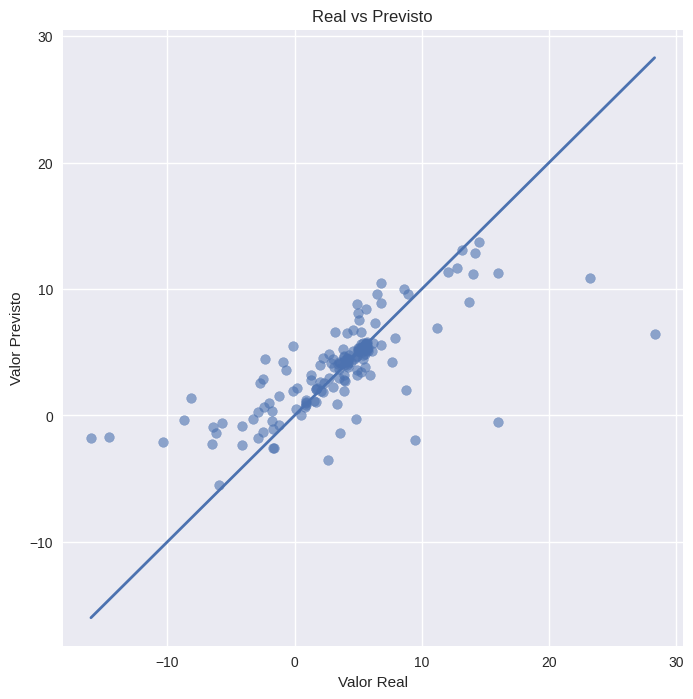

In [35]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [
        y_test.min(),
        y_test.max()
    ],
    [
        y_test.min(),
        y_test.max()
    ],
    linewidth=2
)

plt.xlabel("Valor Real")

plt.ylabel("Valor Previsto")

plt.title(
    "Real vs Previsto"
)

plt.show()

## 9.4 Resíduos

In [36]:
residuals = y_test - y_pred

print(
    residuals.describe()
)

count    163.000000
mean      -0.344376
std        3.812235
min      -14.225333
25%       -1.456667
50%       -0.197333
75%        0.487500
max       21.851333
Name: returns_1yr, dtype: float64


## 9.5 Histograma dos Resíduos

Os resíduos representam a diferença entre os valores observados e os valores previstos pelo modelo.

Idealmente, espera-se que estejam distribuídos em torno de zero, indicando ausência de viés sistemático.


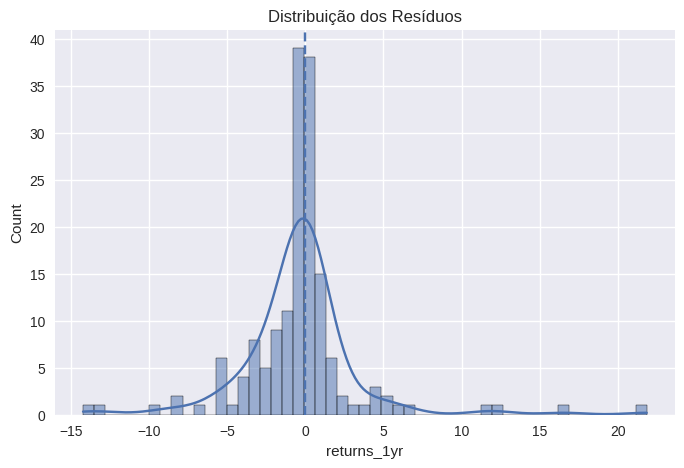

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Distribuição dos Resíduos"
)

plt.show()

## 9.6 Resíduos x Predições

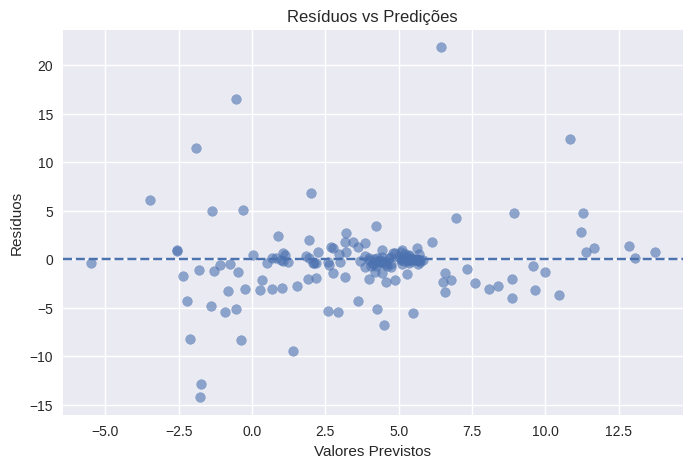

In [38]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Valores Previstos"
)

plt.ylabel(
    "Resíduos"
)

plt.title(
    "Resíduos vs Predições"
)

plt.show()

## 9.7 Overfitting

In [39]:
train_pred = final_model.predict(
    X_train
)

train_r2 = r2_score(
    y_train,
    train_pred
)

test_r2 = r2_score(
    y_test,
    y_pred
)

gap = train_r2 - test_r2

print("Train R² :", round(train_r2,3))
print("Test R²  :", round(test_r2,3))
print("Gap      :", round(gap,3))

Train R² : 0.869
Test R²  : 0.517
Gap      : 0.352


## 9.8 Importância das Variáveis

In [40]:
rf = final_model.named_steps["model"]

feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
)

importance.head(15)

,feature,importance
7,num__sd,0.260364
6,num__alpha,0.162596
13,num__returns_5yr,0.100528
8,num__beta,0.086364
15,num__risk_return_ratio,0.053013
12,num__returns_3yr,0.040864
5,num__sortino,0.039295
17,num__expense_per_rating,0.035074
2,num__expense_ratio,0.029960
10,num__risk_level,0.024657


## 9.9 Top 15 Variáveis

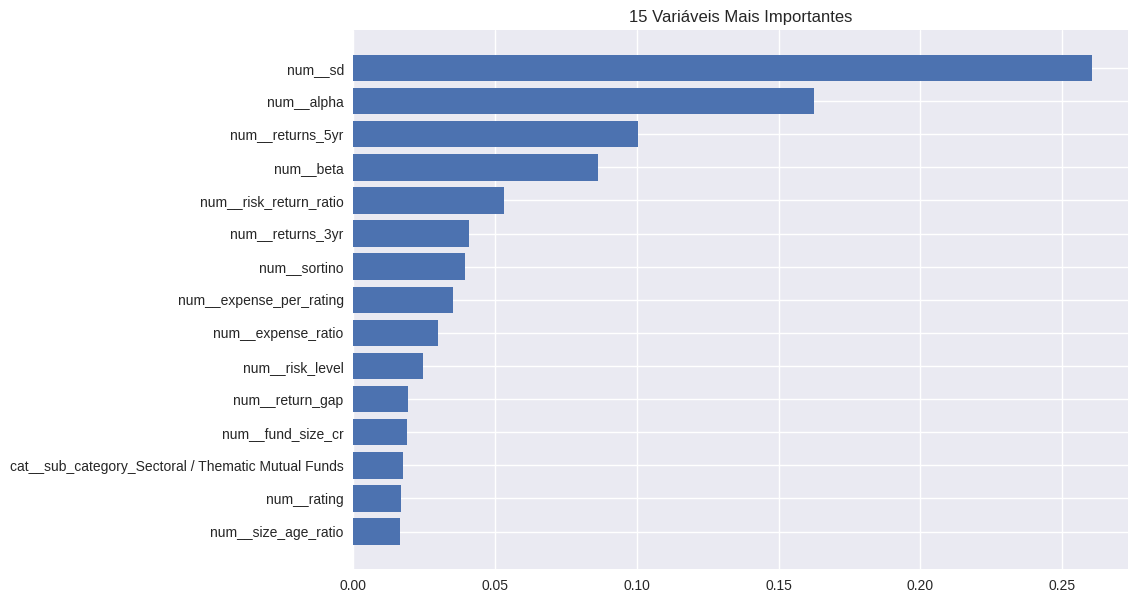

In [41]:
top_features = (
    importance
    .head(15)
    .sort_values(
        "importance"
    )
)

plt.figure(figsize=(10,7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "15 Variáveis Mais Importantes"
)

plt.show()

## 9.10 Tabela Resumo

In [42]:
summary = pd.DataFrame({

    "Métrica":[
        "R² Teste",
        "MAE",
        "RMSE",
        "Train R²",
        "Gap Overfitting"
    ],

    "Valor":[
        final_r2,
        final_mae,
        final_rmse,
        train_r2,
        gap
    ]
})

summary

,Métrica,Valor
0,R² Teste,0.516811
1,MAE,2.087072
2,RMSE,3.816093
3,Train R²,0.868641
4,Gap Overfitting,0.351830


## 9.11 Interpretação dos Resultados

O modelo Random Forest selecionado como solução final apresentou desempenho satisfatório para o problema proposto.

No conjunto de teste foram obtidos os seguintes resultados:

* R² = 0,517;
* MAE = 2,087;
* RMSE = 3,816.

Esses valores indicam que o modelo foi capaz de explicar aproximadamente 52% da variabilidade observada nos retornos anuais dos fundos de investimento.

Considerando a natureza altamente dinâmica e incerta dos mercados financeiros, esse resultado pode ser considerado relevante, uma vez que fatores externos não observados também influenciam o comportamento dos retornos.

A análise dos resíduos mostrou distribuição aproximadamente centrada em zero, com média de -0,344, sugerindo ausência de viés sistemático significativo nas previsões realizadas.

A comparação entre desempenho de treinamento e teste revelou um R² de 0,869 no treinamento e 0,517 no teste, resultando em um gap de aproximadamente 0,352. Esse resultado indica a presença de overfitting moderado, situação comum em modelos baseados em árvores de decisão.

Entretanto, como o desempenho no conjunto de teste permaneceu consistente e alinhado aos resultados observados na validação cruzada, conclui-se que o modelo mantém capacidade adequada de generalização.

A análise de importância das variáveis revelou que os atributos mais relevantes para a previsão da rentabilidade anual foram:

1. Desvio padrão (SD);
2. Alpha;
3. Retorno acumulado em 5 anos;
4. Beta;
5. Relação risco-retorno (Risk Return Ratio).

Alinhados às práticas de análise de investimentos, estes resultados comprovam a solidez econômica das previsões do modelo.

Além disso, a variável derivada Risk Return Ratio, criada durante a etapa de engenharia de atributos, figurou entre as características mais importantes do modelo, evidenciando o impacto positivo da criação de novos atributos sobre a capacidade preditiva da solução.


# 10. Conclusão

O presente trabalho teve como objetivo desenvolver um MVP de Machine Learning capaz de prever a rentabilidade anual de fundos de investimento a partir de indicadores de risco, desempenho histórico, características estruturais e métricas de gestão.

Para atingir esse objetivo, foi conduzido um processo completo de Ciência de Dados, abrangendo as etapas de compreensão do problema, análise exploratória, preparação dos dados, engenharia de atributos, treinamento de modelos, otimização de hiperparâmetros e interpretação dos resultados.

Inicialmente, foi realizada uma análise exploratória do conjunto de dados, permitindo identificar características relevantes dos fundos, padrões de distribuição dos retornos e possíveis relações entre as variáveis explicativas e a variável-alvo.

Na etapa de preparação dos dados, foram aplicadas técnicas de tratamento de valores ausentes, codificação de variáveis categóricas e padronização dos atributos numéricos por meio de pipelines, garantindo um processo reproduzível e livre de vazamento de informações entre os conjuntos de treinamento e teste.

Também foram desenvolvidas novas variáveis derivadas através de engenharia de atributos, buscando representar relações financeiras relevantes entre risco, retorno, porte e eficiência operacional dos fundos. Entre elas, destaca-se a variável Risk Return Ratio, que posteriormente figurou entre os atributos mais importantes para as previsões realizadas pelo modelo.

Foram avaliados diferentes algoritmos de regressão, incluindo Dummy Regressor, Ridge Regression, Random Forest e Gradient Boosting. Os resultados demonstraram clara superioridade dos modelos baseados em árvores de decisão em relação aos modelos lineares e ao baseline.

O modelo Random Forest apresentou o melhor equilíbrio entre desempenho e capacidade de generalização, alcançando aproximadamente:

* R² = 0,517;
* MAE = 2,087;
* RMSE = 3,816.

Esses resultados indicam que o modelo foi capaz de explicar cerca de 52% da variabilidade observada nos retornos anuais dos fundos de investimento, desempenho considerado satisfatório diante da elevada complexidade e imprevisibilidade inerentes ao mercado financeiro.

A etapa de otimização de hiperparâmetros confirmou a robustez da solução inicialmente proposta. Embora tenham sido testadas diversas combinações de parâmetros, os ganhos observados foram mínimos, indicando que a configuração original do Random Forest já se encontrava próxima de uma solução adequada para o problema estudado.

A análise de importância das variáveis revelou que indicadores relacionados ao risco e à qualidade da gestão desempenham papel central na previsão dos retornos. Entre os atributos mais relevantes destacaram-se o desvio padrão (SD), o Alpha, o retorno acumulado em cinco anos, o Beta e a variável derivada Risk Return Ratio.

Os resultados obtidos demonstram que técnicas de Machine Learning podem contribuir de forma significativa para a análise de fundos de investimento, oferecendo suporte quantitativo à identificação de fatores associados à rentabilidade futura.

Como limitações deste estudo, destaca-se a utilização de uma base de dados relativamente pequena e a ausência de variáveis macroeconômicas, fatores de mercado e informações temporais mais detalhadas, que poderiam ampliar o poder explicativo dos modelos.

Como trabalhos futuros, recomenda-se explorar algoritmos mais avançados, como XGBoost, LightGBM e CatBoost, além da incorporação de indicadores econômicos e séries temporais capazes de representar melhor a dinâmica dos mercados financeiros.

Conclui-se, portanto, que o objetivo proposto foi alcançado com sucesso, sendo possível construir um modelo preditivo consistente, interpretável e aderente às boas práticas de Machine Learning, capaz de fornecer estimativas úteis para a análise de rentabilidade de fundos de investimento.
